# Creating Graphs from model results

In this notebook, first the model created by model.ipynb is imported and then the visualisations are created.

## importing requried packages

In [1]:
import linopy
import pypsa

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd

import cartopy
import cartopy.crs as ccrs

import networkx as nx

import atlite
from atlite.gis import ExclusionContainer, shape_availability
from rasterio.plot import show
from rasterio.crs import CRS
import rasterio as rio

from pathlib import Path
import xarray as xr

## Importing the models

In [78]:
n = pypsa.Network("pypsa_model_n.nc") # the model without CO2 limitations
n_no_co2 = pypsa.Network("pypsa_model_n_no_co2.nc") # the model with CO2 limitation of 0

print(f"\nobjective of model n: {(n.objective / 1e9):.2f} Mrd. €")
print(f"objective of model n: {(n_no_co2.objective / 1e9):.2f} Mrd. €")

INFO:pypsa.network.io:New version 1.0.7 available! (Current: 1.0.5)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, links, loads, storage_units, sub_networks
INFO:pypsa.network.io:New version 1.0.7 available! (Current: 1.0.5)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, links, loads, storage_units, sub_networks



objective of model n: 7.26 Mrd. €
objective of model n: 25.12 Mrd. €


## preparing regional data

In [194]:
# preparing the data of states of Iran (gadm)
url_gadm_local = Path("data") / "gadm_410-levels-ADM_1-IRN.gpkg"
gadm_ir = gpd.read_file(url_gadm_local)
gadm_ir["bus"] = gadm_ir.geometry.representative_point() # to be used as bus for modeling

# exclusiv economic zone (eez)
url_eez_ir_local = Path("data") / "eez_ir.gpkg"
eez_ir = gpd.read_file(url_eez_ir_local)
eez_ir["bus"] = eez_ir.geometry.representative_point() # defining the representative of eez in north and south to be used as bus for pypsa



## loads and links

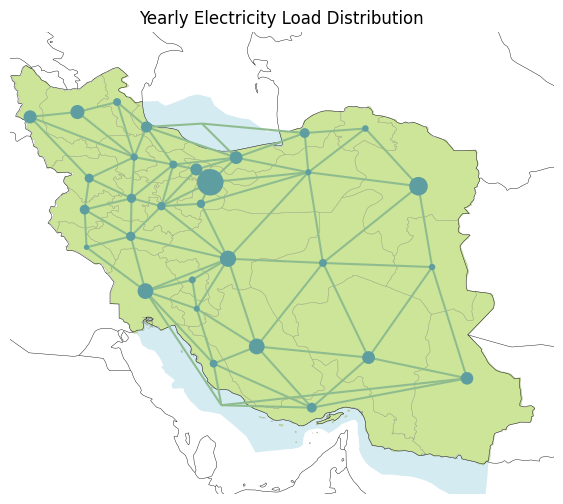

In [214]:
fig = plt.figure(figsize=(10, 6)) 
ax = plt.axes(projection = ccrs.PlateCarree())

gadm_ir.plot(ax=ax, color="yellowgreen", label="States of Iran", alpha=0.5, edgecolor="gray", linewidth=0.3)
eez_ir.plot(ax=ax, color="lightblue", label="Exclusive Economic Zones of Iran", alpha=0.5)

load = n.loads_t.p_set.sum(axis=0).groupby(n.loads.bus).sum()
n.plot(ax=ax, bus_size=load/1e8)

ax.set_title("Yearly Electricity Load Distribution")
ax.set_extent([44, 64, 24, 41], crs=ccrs.PlateCarree())

## Generation and links

### Existing Power Plants

/Users/morteza/DSESM-venv-312/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning:

facecolor will have no effect as it has been defined as "never".



Text(0.5, 1.0, 'Location of power plants and their primary fuel')

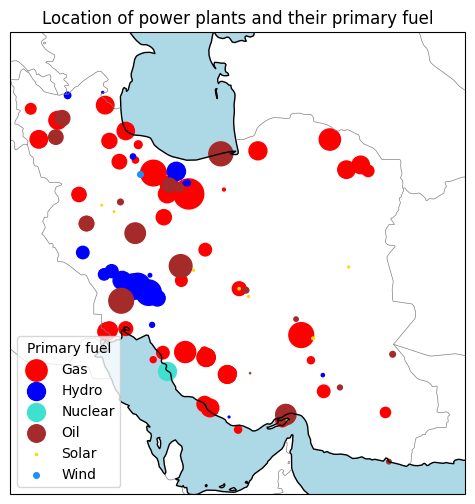

In [196]:
fuel_colors = {
    "Gas": "red",
    "Hydro": "blue",
    "Nuclear": "turquoise",
    "Oil": "brown",
    "Solar": "gold",
    "Wind": "dodgerblue",
}

fig = plt.figure(figsize=(10, 6))
ax = plt.axes(projection=ccrs.epsg(3857))

pp_ir_3857 = pp_ir.to_crs(epsg=3857)

for fuel, color in fuel_colors.items():
    subset = pp_ir_3857[pp_ir_3857["primary_fuel"] == fuel]
    if not subset.empty:
        subset.plot(
            ax=ax,
            color=color,
            markersize=subset["capacity_mw"] / 6,
            label=fuel,
        )

ax.coastlines()
ax.add_feature(cartopy.feature.OCEAN, color="lightblue", linewidth=0.3)
ax.add_feature(cartopy.feature.BORDERS, color="grey", linewidth=0.5)

ax.legend(
    title="Primary fuel",
    loc="lower left",
    frameon=True,
)

ax.set_extent([44, 64, 24, 41], crs=ccrs.PlateCarree())
ax.set_title("Location of power plants and their primary fuel")


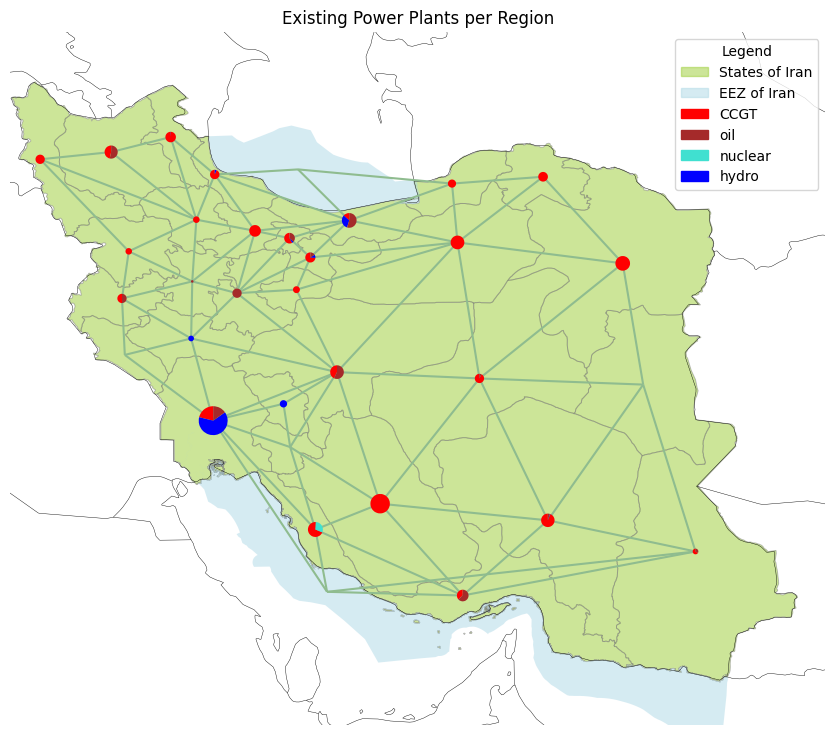

In [237]:
fig = plt.figure(figsize=(15, 9)) 
ax = plt.axes(projection = ccrs.PlateCarree())

gadm_ir.plot(ax=ax, color="yellowgreen", label="States of Iran", alpha=0.5, edgecolor="gray", linewidth=0.7)
eez_ir.plot(ax=ax, color="lightblue", label="Exclusive Economic Zones of Iran", alpha=0.5)

re_cap_potentials = n.generators.groupby(["bus", "carrier"]).p_nom.sum()
re_cap_potentials = re_cap_potentials.loc[re_cap_potentials.index.get_level_values("carrier").isin(["CCGT", "oil", "hydro", "nuclear"])]
n.plot(ax=ax, bus_size=re_cap_potentials/1e5)

ax.set_title("Existing Power Plants per Region")
ax.set_extent([44, 64, 24, 41], crs=ccrs.PlateCarree())

wanted_carriers = ["CCGT", "oil", "hydro", "nuclear"]
carrier_legend = [
    mpatches.Patch(
        color=row.color,
        label=carrier
    )
    for carrier, row in n.carriers.iterrows()
    if carrier in wanted_carriers and pd.notna(row.color)
]

map_legend = [
    mpatches.Patch(color="yellowgreen", label="States of Iran", alpha=0.5),
    mpatches.Patch(color="lightblue", label="EEZ of Iran", alpha=0.5),
]

ax.legend(
    handles=map_legend + carrier_legend,
    title="Legend",
    #loc="lower left",
    frameon=True
)

### Model n (without CO2 Limit)

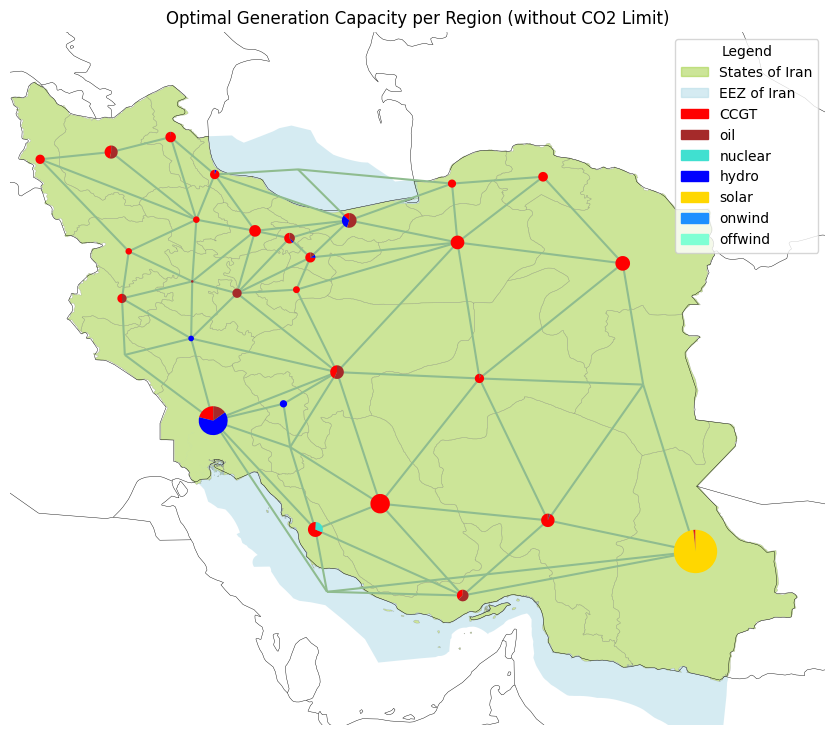

In [232]:
fig = plt.figure(figsize=(15, 9)) 
ax = plt.axes(projection = ccrs.PlateCarree())

gadm_ir.plot(ax=ax, color="yellowgreen", label="States of Iran", alpha=0.5, edgecolor="gray", linewidth=0.3)
eez_ir.plot(ax=ax, color="lightblue", label="Exclusive Economic Zones of Iran", alpha=0.5)

capacities = n.generators.groupby(["bus", "carrier"]).p_nom_opt.sum()
n.plot(ax=ax, bus_size=capacities/1e5)


ax.set_title("Optimal Generation Capacity per Region (without CO2 Limit)")
ax.set_extent([44, 64, 24, 41], crs=ccrs.PlateCarree())

import matplotlib.patches as mpatches

wanted_carriers = ["CCGT", "oil", "nuclear", "hydro", "solar", "onwind", "offwind"]
carrier_legend = [
    mpatches.Patch(
        color=row.color,
        label=carrier
    )
    for carrier, row in n.carriers.iterrows()
    if carrier in wanted_carriers and pd.notna(row.color)
]

map_legend = [
    mpatches.Patch(color="yellowgreen", label="States of Iran", alpha=0.5),
    mpatches.Patch(color="lightblue", label="EEZ of Iran", alpha=0.5),
]

ax.legend(
    handles=map_legend + carrier_legend,
    title="Legend",
    #loc="lower left",
    frameon=True
)

### Model n_no_co2 (with CO2 Limit of 0)

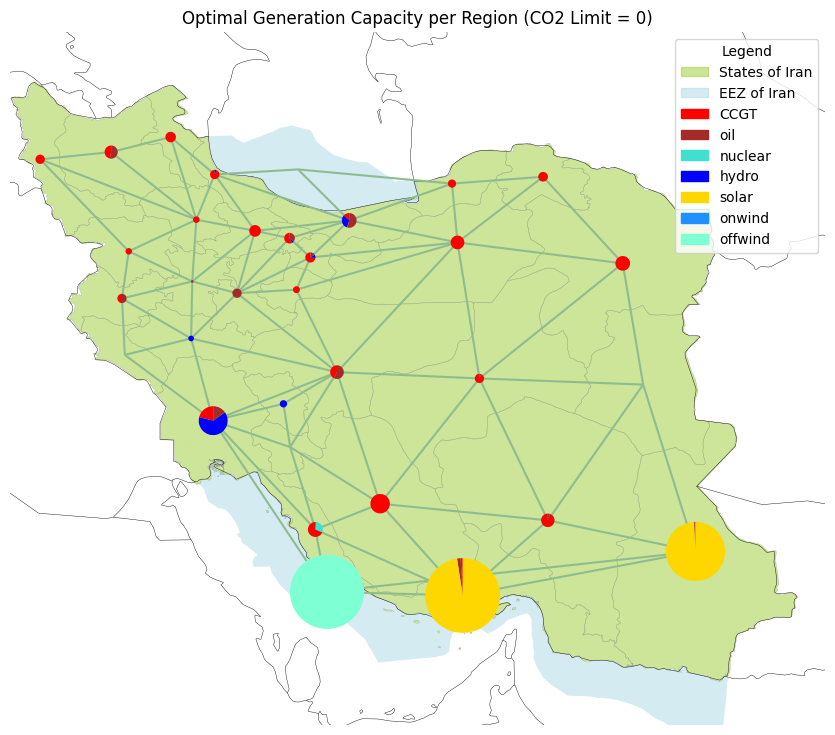

In [233]:
fig = plt.figure(figsize=(15, 9)) 
ax = plt.axes(projection = ccrs.PlateCarree())

gadm_ir.plot(ax=ax, color="yellowgreen", label="States of Iran", alpha=0.5, edgecolor="gray", linewidth=0.3)
eez_ir.plot(ax=ax, color="lightblue", label="Exclusive Economic Zones of Iran", alpha=0.5)

capacities_no_co2 = n_no_co2.generators.groupby(["bus", "carrier"]).p_nom_opt.sum()
n_no_co2.plot(ax=ax, bus_size=capacities_no_co2/1e5)

ax.set_title("Optimal Generation Capacity per Region (CO2 Limit = 0)")
ax.set_extent([44, 64, 24, 41], crs=ccrs.PlateCarree())

wanted_carriers = ["CCGT", "oil", "nuclear", "hydro", "solar", "onwind", "offwind"]
carrier_legend = [
    mpatches.Patch(
        color=row.color,
        label=carrier
    )
    for carrier, row in n.carriers.iterrows()
    if carrier in wanted_carriers and pd.notna(row.color)
]

map_legend = [
    mpatches.Patch(color="yellowgreen", label="States of Iran", alpha=0.5),
    mpatches.Patch(color="lightblue", label="EEZ of Iran", alpha=0.5),
]

ax.legend(
    handles=map_legend + carrier_legend,
    title="Legend",
    #loc="lower left",
    frameon=True
)

## RE Potentials

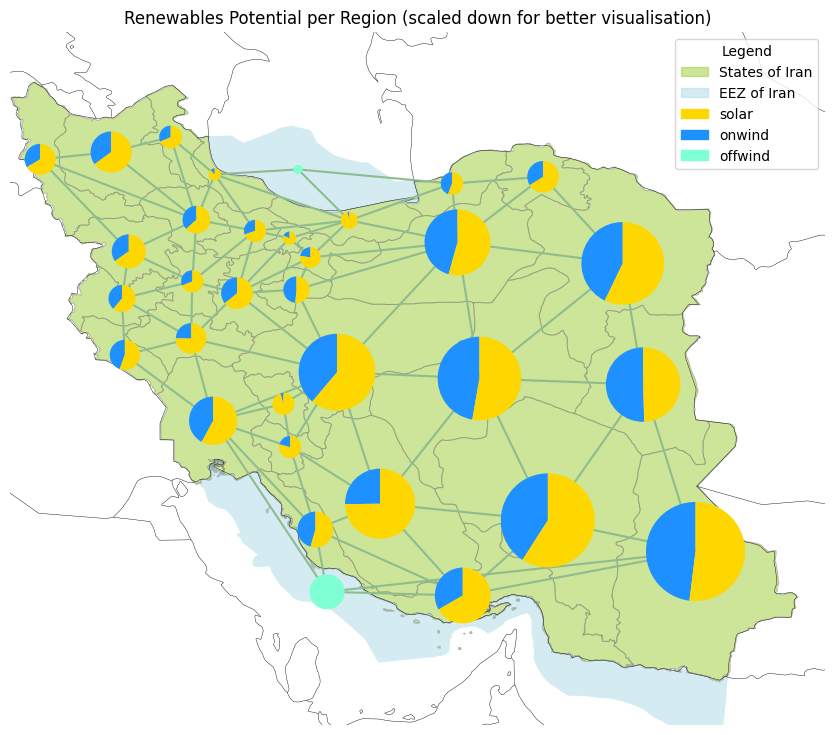

In [ ]:
fig = plt.figure(figsize=(15, 9)) 
ax = plt.axes(projection = ccrs.PlateCarree())

gadm_ir.plot(ax=ax, color="yellowgreen", label="States of Iran", alpha=0.5, edgecolor="gray", linewidth=0.7)
eez_ir.plot(ax=ax, color="lightblue", label="Exclusive Economic Zones of Iran", alpha=0.5)

re_cap_potentials = n.generators.groupby(["bus", "carrier"]).p_nom_max.sum()
re_cap_potentials = re_cap_potentials.loc[re_cap_potentials.index.get_level_values("carrier").isin(["solar", "onwind", "offwind"])]
n.plot(ax=ax, bus_size=re_cap_potentials/5e5)

ax.set_title("Renewables Potential per Region (scaled down for better visualisation)")
ax.set_extent([44, 64, 24, 41], crs=ccrs.PlateCarree())

wanted_carriers = ["solar", "onwind", "offwind"]
carrier_legend = [
    mpatches.Patch(
        color=row.color,
        label=carrier
    )
    for carrier, row in n.carriers.iterrows()
    if carrier in wanted_carriers and pd.notna(row.color)
]

map_legend = [
    mpatches.Patch(color="yellowgreen", label="States of Iran", alpha=0.5),
    mpatches.Patch(color="lightblue", label="EEZ of Iran", alpha=0.5),
]

ax.legend(
    handles=map_legend + carrier_legend,
    title="Legend",
    #loc="lower left",
    frameon=True
)

## Power Flow

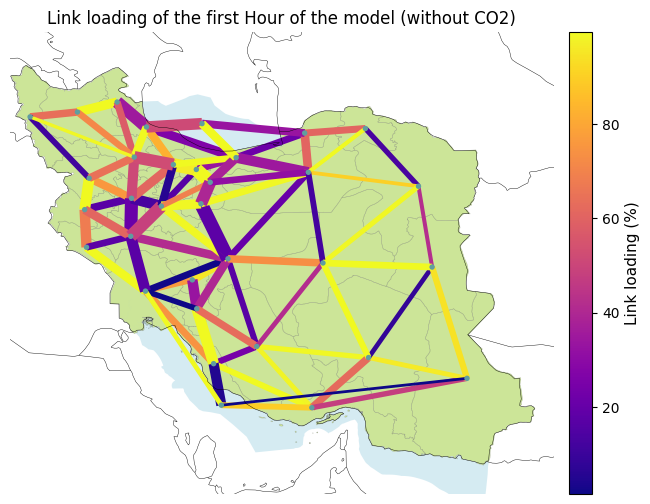

In [361]:
import numpy as np

fig = plt.figure(figsize=(10, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

gadm_ir.plot(ax=ax, color="yellowgreen", alpha=0.5, edgecolor="gray", linewidth=0.3)
eez_ir.plot(ax=ax, color="lightblue", alpha=0.5)

# loading showed by color
loading_pct = n.links_t.p0.iloc[0].abs() / n.links.p_nom_opt / n.links.p_max_pu * 100  # %

# widths (visible scaling)
link_w = (n.links.p_nom_opt / 1000)

# ---- pass 1: draw links (thick, no arrows) ----
n.plot(
    ax=ax,
    bus_size=1e-2,
    link_color=loading_pct,
    link_cmap="plasma",
    link_width=link_w / 30,     # keep line width
    link_flow=0,           # <-- suppress arrows
    auto_scale_branches=False,
)

import matplotlib as mpl

# --- create a ScalarMappable for the colorbar ---
norm = mpl.colors.Normalize(
    vmin=loading_pct.min(),
    vmax=loading_pct.max()
)

sm = mpl.cm.ScalarMappable(
    cmap="plasma",
    norm=norm
)
sm.set_array([])  # required for matplotlib
cbar = fig.colorbar(
    sm,
    ax=ax,
    orientation="vertical",
    fraction=0.035,
    pad=0.02
)

cbar.set_label("Link loading (%)", fontsize=11)

ax.set_title("Link loading of the first Hour of the model (without CO2)")
ax.set_extent([44, 64, 24, 41], crs=ccrs.PlateCarree())


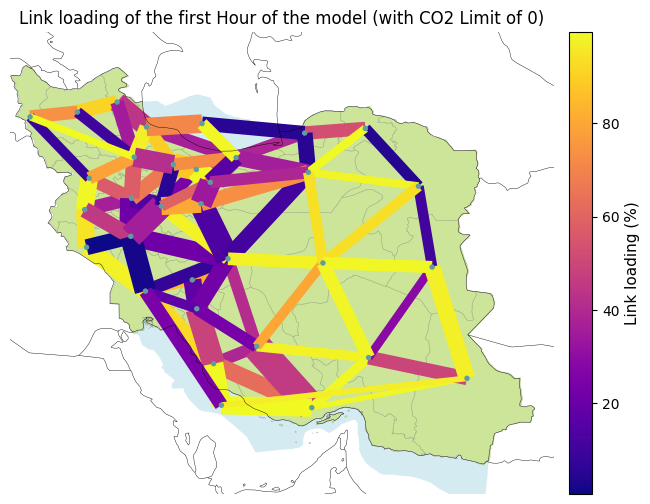

In [363]:
import numpy as np

fig = plt.figure(figsize=(10, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

gadm_ir.plot(ax=ax, color="yellowgreen", alpha=0.5, edgecolor="gray", linewidth=0.3)
eez_ir.plot(ax=ax, color="lightblue", alpha=0.5)

# loading showed by color
loading_pct = n_no_co2.links_t.p0.iloc[0].abs() / n_no_co2.links.p_nom_opt / n_no_co2.links.p_max_pu * 100  # %

# widths (visible scaling)
link_w = (n_no_co2.links.p_nom_opt / 1000)

# ---- pass 1: draw links (thick, no arrows) ----
n_no_co2.plot(
    ax=ax,
    bus_size=1e-2,
    link_color=loading_pct,
    link_cmap="plasma",
    link_width=link_w / 30,     # keep line width
    link_flow=0,           # <-- suppress arrows
    auto_scale_branches=False,
)

import matplotlib as mpl

# --- create a ScalarMappable for the colorbar ---
norm = mpl.colors.Normalize(
    vmin=loading_pct.min(),
    vmax=loading_pct.max()
)

sm = mpl.cm.ScalarMappable(
    cmap="plasma",
    norm=norm
)
sm.set_array([])  # required for matplotlib
cbar = fig.colorbar(
    sm,
    ax=ax,
    orientation="vertical",
    fraction=0.035,
    pad=0.02
)

cbar.set_label("Link loading (%)", fontsize=11)

ax.set_title("Link loading of the first Hour of the model (with CO2 Limit of 0)")
ax.set_extent([44, 64, 24, 41], crs=ccrs.PlateCarree())
